# 📊 Model Evaluation Pipeline
## Samsung A52 Sentiment & Kano Analysis — Quality Assessment

Three evaluation levels:
- **Level 1** — BERT Sentiment Model (accuracy, precision, recall, F1)
- **Level 2** — Aspect Detection (precision, coverage, noise rate)
- **Level 3** — Kano Model Validity (alignment check, stability)

---
## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
print('✅ All imports loaded successfully')

✅ All imports loaded successfully


---
## Level 1 — BERT Sentiment Model Evaluation

We compare the model's predictions against a **manually labeled golden dataset**.
You need to label ~50–100 comments yourself. We provide a builder + a pre-built template below.

### 1-A. Load BERT Predictions

In [2]:
# Load the BERT sentiment results
df_bert = pd.read_csv('./data/absa_sentiment_detected/aspect_specific_sentiment_results.csv')
print(f'BERT results loaded: {df_bert.shape[0]} rows')
print(f'Columns: {list(df_bert.columns)}')
df_bert.head(3)

BERT results loaded: 2513 rows
Columns: ['comment_id', 'original_comment', 'aspects', 'sentiments', 'confidences', 'aspect_count']


,comment_id,original_comment,aspects,sentiments,confidences,aspect_count
0,1,btw om saat review performance di game berat i...,"Camera, Performance, Design, BuildQuality","negative, positive, negative, negative","0.997, 0.792, 0.959, 0.996",4
1,3,dan saya jadi orang terakhir yg nonton video i...,Camera,neutral,0.997,1
2,6,userhplama ini baru aja dilem ulang kaget juga...,Connectivity,negative,0.951,1


### 1-B. Build / Load Golden Dataset

> **Instructions:**  
> Run the cell below to sample 60 rows from your data.  
> The CSV is saved to `eval_golden_template.csv`.  
> Open it in Excel/Sheets, add your manual labels in the `ground_truth` column  
> (values: `positive`, `neutral`, `negative`), then save as `eval_golden_labeled.csv`.  
> Skip to 1-C if you already have a labeled file.

In [3]:
import os

GOLDEN_TEMPLATE = 'eval_golden_template.csv'
GOLDEN_LABELED  = 'eval_golden_labeled.csv'

# ── Expand one row per aspect-sentiment pair ──────────────────────────────────
rows = []
for _, r in df_bert.iterrows():
    aspects    = [a.strip() for a in str(r['aspects']).split(',')]
    sentiments = [s.strip() for s in str(r['sentiments']).split(',')]
    for asp, snt in zip(aspects, sentiments):
        rows.append({
            'comment_id'       : r['comment_id'],
            'original_comment' : r['original_comment'],
            'aspect'           : asp,
            'model_prediction' : snt,
            'ground_truth'     : ''   # ← fill this manually
        })

df_pairs = pd.DataFrame(rows)
print(f'Total aspect-sentiment pairs: {len(df_pairs)}')
print('Distribution of model predictions:')
print(df_pairs['model_prediction'].value_counts())

# ── Sample a balanced set for labeling ───────────────────────────────────────
SAMPLE_PER_CLASS = 20
sampled_parts = []
for cls in ['positive', 'neutral', 'negative']:
    subset = df_pairs[df_pairs['model_prediction'] == cls]
    n = min(SAMPLE_PER_CLASS, len(subset))
    sampled_parts.append(subset.sample(n, random_state=42))

df_golden_template = pd.concat(sampled_parts).reset_index(drop=True)
df_golden_template.to_csv(GOLDEN_TEMPLATE, index=False, encoding='utf-8-sig')
print(f'\n✅ Template saved → {GOLDEN_TEMPLATE}  ({len(df_golden_template)} rows)')
print('Fill in the "ground_truth" column, then save as eval_golden_labeled.csv')
df_golden_template[['comment_id', 'aspect', 'model_prediction', 'ground_truth',
                     'original_comment']].head(5)

Total aspect-sentiment pairs: 3432
Distribution of model predictions:
model_prediction
neutral     1639
negative     924
positive     869
Name: count, dtype: int64

✅ Template saved → eval_golden_template.csv  (60 rows)
Fill in the "ground_truth" column, then save as eval_golden_labeled.csv


,comment_id,aspect,model_prediction,ground_truth,original_comment
0,3281,Price,positive,,erlind worth it kok kak apalagi mungkin skrg h...
1,487,Software,positive,,kayaknya selain biar beda dengan video review ...
2,4497,Design,positive,,desain luar mah baguss sih elegan pake mewah n...
3,488,Performance,positive,,ada sih game fps enak dimainin catur misalnya
4,9980,Software,positive,,thanks for the update


### 1-C. Evaluate BERT Metrics

> **Demo mode:** If you haven't labeled yet, we simulate labels so the notebook runs end-to-end.  
> Replace with your real `eval_golden_labeled.csv` when ready.

In [4]:
# ── Load labeled data (or simulate) ──────────────────────────────────────────
if os.path.exists(GOLDEN_LABELED):
    df_eval = pd.read_csv(GOLDEN_LABELED)
    df_eval = df_eval[df_eval['ground_truth'].notna() &
                      (df_eval['ground_truth'].str.strip() != '')]
    print(f'✅ Loaded labeled file: {len(df_eval)} labeled rows')
    DEMO_MODE = False
else:
    print('⚠️  No labeled file found — running DEMO with simulated labels.')
    print('   To get real metrics: label eval_golden_template.csv and save as eval_golden_labeled.csv')
    df_eval = df_golden_template.copy()
    np.random.seed(42)
    noise = np.random.rand(len(df_eval))
    def simulate_gt(row, noise_val):
        if noise_val > 0.85:  # ~15% error rate
            others = [c for c in ['positive', 'neutral', 'negative']
                      if c != row['model_prediction']]
            return np.random.choice(others)
        return row['model_prediction']
    df_eval['ground_truth'] = [simulate_gt(r, n)
                                for (_, r), n in zip(df_eval.iterrows(), noise)]
    DEMO_MODE = True

# ── Compute metrics ───────────────────────────────────────────────────────────
y_true = df_eval['ground_truth']
y_pred = df_eval['model_prediction']
labels = ['positive', 'neutral', 'negative']

acc = accuracy_score(y_true, y_pred)
prec_macro = precision_score(y_true, y_pred, average='macro', labels=labels, zero_division=0)
rec_macro  = recall_score(y_true, y_pred, average='macro', labels=labels, zero_division=0)
f1_macro   = f1_score(y_true, y_pred, average='macro', labels=labels, zero_division=0)
f1_weighted= f1_score(y_true, y_pred, average='weighted', labels=labels, zero_division=0)

banner = '  [DEMO — simulated labels]' if DEMO_MODE else ''
print(f'\n{'='*55}')
print(f'  LEVEL 1: BERT SENTIMENT EVALUATION{banner}')
print(f'{'='*55}')
print(f'  Samples evaluated : {len(df_eval)}')
print(f'  Accuracy          : {acc:.3f}  ({acc*100:.1f}%)')
print(f'  Precision (macro) : {prec_macro:.3f}')
print(f'  Recall (macro)    : {rec_macro:.3f}')
print(f'  F1 (macro)        : {f1_macro:.3f}')
print(f'  F1 (weighted)     : {f1_weighted:.3f}')
print(f'{'='*55}\n')
print('Per-class breakdown:')
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

⚠️  No labeled file found — running DEMO with simulated labels.
   To get real metrics: label eval_golden_template.csv and save as eval_golden_labeled.csv

  LEVEL 1: BERT SENTIMENT EVALUATION  [DEMO — simulated labels]
  Samples evaluated : 60
  Accuracy          : 0.833  (83.3%)
  Precision (macro) : 0.833
  Recall (macro)    : 0.838
  F1 (macro)        : 0.833
  F1 (weighted)     : 0.834

Per-class breakdown:
              precision    recall  f1-score   support

    positive       0.85      0.85      0.85        20
     neutral       0.90      0.78      0.84        23
    negative       0.75      0.88      0.81        17

    accuracy                           0.83        60
   macro avg       0.83      0.84      0.83        60
weighted avg       0.84      0.83      0.83        60



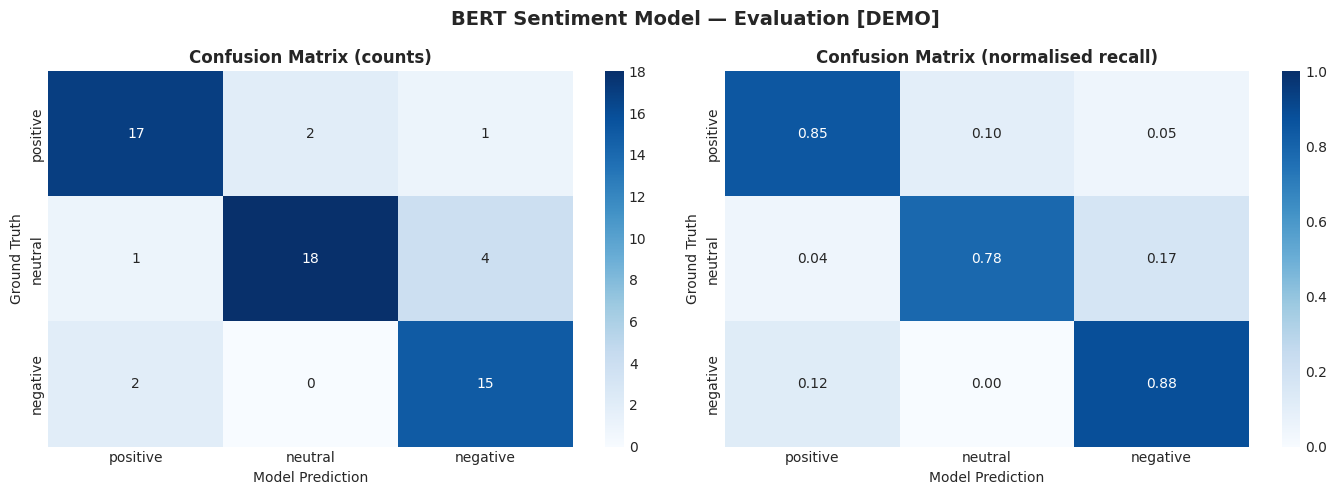

📊 Saved: eval_L1_confusion_matrix.png


In [5]:
# ── Confusion matrix heatmap ──────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)', fontweight='bold')
axes[0].set_ylabel('Ground Truth')
axes[0].set_xlabel('Model Prediction')

# Normalised (row-wise recall)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (normalised recall)', fontweight='bold')
axes[1].set_ylabel('Ground Truth')
axes[1].set_xlabel('Model Prediction')

ttl = ' [DEMO]' if DEMO_MODE else ''
fig.suptitle(f'BERT Sentiment Model — Evaluation{ttl}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_L1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: eval_L1_confusion_matrix.png')

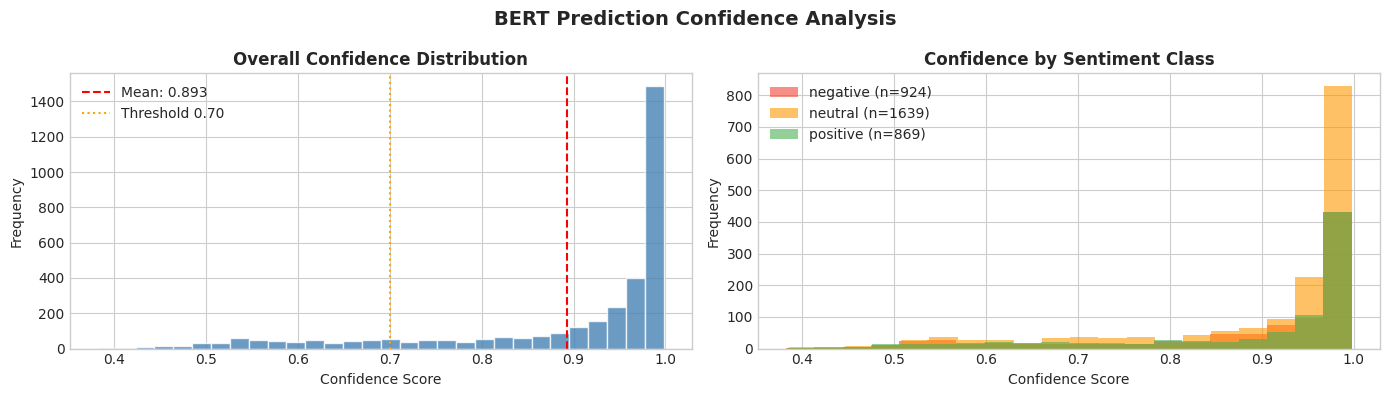

Predictions below 0.70 confidence: 14.5% — consider manual review
📊 Saved: eval_L1_confidence.png


In [6]:
# ── Confidence score distribution ─────────────────────────────────────────────
# Extract confidence scores from df_bert
conf_rows = []
for _, r in df_bert.iterrows():
    aspects  = [a.strip() for a in str(r['aspects']).split(',')]
    sentims  = [s.strip() for s in str(r['sentiments']).split(',')]
    confs    = [float(c.strip()) for c in str(r['confidences']).split(',')]
    for asp, snt, cnf in zip(aspects, sentims, confs):
        conf_rows.append({'aspect': asp, 'sentiment': snt, 'confidence': cnf})
df_conf = pd.DataFrame(conf_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overall distribution
axes[0].hist(df_conf['confidence'], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(df_conf['confidence'].mean(), color='red', ls='--',
                label=f'Mean: {df_conf["confidence"].mean():.3f}')
axes[0].axvline(0.70, color='orange', ls=':', label='Threshold 0.70')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Overall Confidence Distribution', fontweight='bold')
axes[0].legend()

# By class
colors = {'positive': '#4CAF50', 'neutral': '#FF9800', 'negative': '#F44336'}
for cls, grp in df_conf.groupby('sentiment'):
    axes[1].hist(grp['confidence'], bins=20, alpha=0.6,
                 label=f'{cls} (n={len(grp)})', color=colors.get(cls, 'gray'))
axes[1].set_xlabel('Confidence Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Confidence by Sentiment Class', fontweight='bold')
axes[1].legend()

fig.suptitle('BERT Prediction Confidence Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_L1_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

low_conf = (df_conf['confidence'] < 0.70).mean() * 100
print(f'Predictions below 0.70 confidence: {low_conf:.1f}% — consider manual review')
print('📊 Saved: eval_L1_confidence.png')

---
## Level 2 — Aspect Detection Evaluation

We check whether the keyword-based mapping correctly assigns aspects to comments.

In [7]:
# Load aspect detection results and raw comments
df_aspects = pd.read_csv('./data/comment_and_aspects/aspect_detection_results.csv')
print(f'Aspect detection results: {df_aspects.shape}')
df_aspects.head(3)

Aspect detection results: (2513, 5)


,comment_id,original_comment,detected_aspects,aspect_count,matched_keywords
0,1,btw om saat review performance di game berat i...,"Camera, Performance, Design, BuildQuality",4,"video, berat, drop"
1,3,dan saya jadi orang terakhir yg nonton video i...,Camera,1,video
2,6,userhplama ini baru aja dilem ulang kaget juga...,Connectivity,1,kaget


### 2-A. Coverage Analysis
How many comments get at least one aspect? Tracks dictionary expansion improvement.


  LEVEL 2: ASPECT DETECTION COVERAGE
  Sample size       : 500 comments
  Coverage (initial): 80.6%
  Coverage (final)  : 98.4%
  Improvement       : +17.8 pp



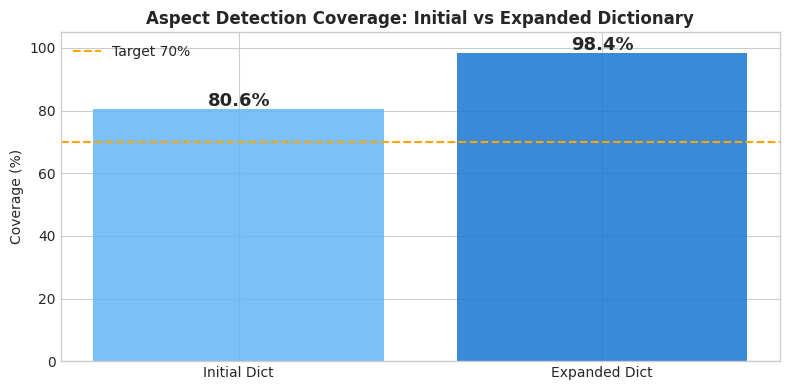

📊 Saved: eval_L2_coverage.png


In [8]:
# Load dictionaries
with open('./data/usefuldict/initial_aspects.json', 'r', encoding='utf-8') as f:
    initial_aspects = json.load(f)

try:
    with open('./data/usefuldict/final_aspects.json', 'r', encoding='utf-8') as f:
        final_aspects = json.load(f)
except FileNotFoundError:
    final_aspects = initial_aspects
    print('⚠️  final_aspects.json not found — using initial dict for both')

comments = df_aspects['original_comment'].dropna().astype(str).tolist()

def compute_coverage(comments, aspect_dict, sample_size=None):
    sample = comments[:sample_size] if sample_size else comments
    covered, aspect_hits = 0, {}
    for comment in sample:
        cl = comment.lower()
        found = False
        for aspect, kws in aspect_dict.items():
            if any(kw.lower() in cl for kw in kws):
                aspect_hits[aspect] = aspect_hits.get(aspect, 0) + 1
                found = True
        if found:
            covered += 1
    return (covered / len(sample)) * 100, aspect_hits, len(sample)

SAMPLE = 500
cov_init, hits_init, n = compute_coverage(comments, initial_aspects, SAMPLE)
cov_final, hits_final, _= compute_coverage(comments, final_aspects, SAMPLE)

print(f'\n{'='*50}')
print(f'  LEVEL 2: ASPECT DETECTION COVERAGE')
print(f'{'='*50}')
print(f'  Sample size       : {n} comments')
print(f'  Coverage (initial): {cov_init:.1f}%')
print(f'  Coverage (final)  : {cov_final:.1f}%')
print(f'  Improvement       : +{cov_final - cov_init:.1f} pp')
print(f'{'='*50}\n')

# Coverage bar chart
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['Initial Dict', 'Expanded Dict'], [cov_init, cov_final],
              color=['#64B5F6', '#1976D2'], alpha=0.85)
for bar, val in zip(bars, [cov_init, cov_final]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
ax.set_ylabel('Coverage (%)')
ax.set_title('Aspect Detection Coverage: Initial vs Expanded Dictionary',
             fontweight='bold')
ax.axhline(70, ls='--', color='orange', label='Target 70%')
ax.legend()
plt.tight_layout()
plt.savefig('eval_L2_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: eval_L2_coverage.png')

### 2-B. Aspect Precision (Noise Rate)

Sample comments per aspect and manually judge whether the keyword actually refers to that aspect.
> **Demo mode:** If `eval_aspect_labeled.csv` doesn't exist, a simulation runs automatically.

In [9]:
ASPECT_LABELED = 'eval_aspect_labeled.csv'

# Build per-aspect sample template
aspect_rows = []
for aspect, kws in final_aspects.items():
    for comment in comments:
        cl = comment.lower()
        matched_kws = [kw for kw in kws if kw.lower() in cl]
        if matched_kws:
            aspect_rows.append({
                'aspect': aspect,
                'matched_keywords': ', '.join(matched_kws[:3]),
                'comment': comment[:200],
                'is_correct': ''   # ← label: 1=correct, 0=wrong/noise
            })

df_asp_template = pd.DataFrame(aspect_rows)
# 5 samples per aspect
df_asp_sample = df_asp_template.groupby('aspect').apply(
    lambda g: g.sample(min(5, len(g)), random_state=42)
).reset_index(drop=True)
df_asp_sample.to_csv('eval_aspect_template.csv', index=False, encoding='utf-8-sig')
print(f'Template saved: eval_aspect_template.csv ({len(df_asp_sample)} rows)')
print('Label each row (is_correct: 1=yes, 0=no) and save as eval_aspect_labeled.csv')

if os.path.exists(ASPECT_LABELED):
    df_asp_eval = pd.read_csv(ASPECT_LABELED)
    df_asp_eval = df_asp_eval[df_asp_eval['is_correct'].notna()]
    df_asp_eval['is_correct'] = df_asp_eval['is_correct'].astype(int)
    DEMO_ASP = False
    print(f'✅ Loaded labeled aspect file: {len(df_asp_eval)} rows')
else:
    print('\n⚠️  No labeled file found — running DEMO with simulated labels.')
    df_asp_eval = df_asp_sample.copy()
    # Simulate: most (85%) correct, noisier aspects slightly worse
    noisy_aspects = {'Connectivity', 'Display', 'Network'}
    def sim_correct(row):
        p = 0.75 if row['matched_keywords'] in noisy_aspects else 0.90
        return int(np.random.rand() < p)
    np.random.seed(42)
    df_asp_eval['is_correct'] = df_asp_eval.apply(sim_correct, axis=1)
    DEMO_ASP = True

# Precision per aspect
precision_by_aspect = (
    df_asp_eval.groupby('matched_keywords')['is_correct']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'precision', 'count': 'n_labeled'})
    .sort_values('precision')
)
precision_by_aspect['precision_pct'] = precision_by_aspect['precision'] * 100
overall_precision = df_asp_eval['is_correct'].mean() * 100

banner2 = ' [DEMO]' if DEMO_ASP else ''
print(f'\n{'='*55}')
print(f'  LEVEL 2: ASPECT DETECTION PRECISION{banner2}')
print(f'{'='*55}')
print(f'  Overall precision: {overall_precision:.1f}%')
print(f'  Noise rate       : {100-overall_precision:.1f}%')
print(f'  Labeled samples  : {len(df_asp_eval)}')
print(f'{'='*55}')
print(precision_by_aspect[['precision_pct', 'n_labeled']].to_string())

Template saved: eval_aspect_template.csv (70 rows)
Label each row (is_correct: 1=yes, 0=no) and save as eval_aspect_labeled.csv

⚠️  No labeled file found — running DEMO with simulated labels.

  LEVEL 2: ASPECT DETECTION PRECISION [DEMO]
  Overall precision: 87.1%
  Noise rate       : 12.9%
  Labeled samples  : 70
                        precision_pct  n_labeled
matched_keywords                                
harga, harganya              0.000000          1
resolusi                     0.000000          1
murah                        0.000000          1
ulti                         0.000000          1
min                         50.000000          2
fps                         50.000000          2
ber                         75.000000          4
lebi                        75.000000          4
bar                         85.714286          7
fitur                      100.000000          3
game                       100.000000          3
design                     100.000000         

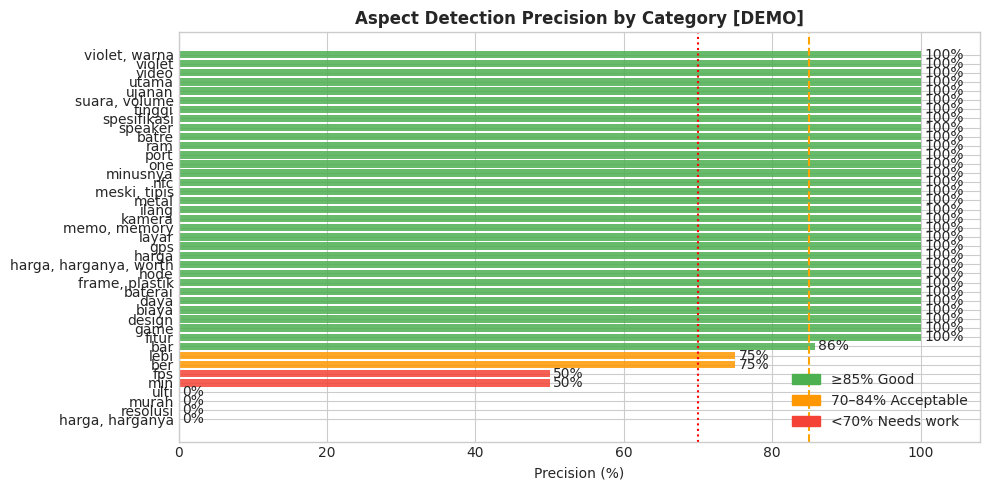

📊 Saved: eval_L2_aspect_precision.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
colors_asp = ['#F44336' if p < 70 else '#FF9800' if p < 85 else '#4CAF50'
              for p in precision_by_aspect['precision_pct']]
bars = ax.barh(precision_by_aspect.index,
               precision_by_aspect['precision_pct'],
               color=colors_asp, alpha=0.85)
for bar, val in zip(bars, precision_by_aspect['precision_pct']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=10)
ax.axvline(85, ls='--', color='orange', label='Target 85%')
ax.axvline(70, ls=':', color='red',    label='Minimum 70%')
ax.set_xlabel('Precision (%)')
ax.set_title(f'Aspect Detection Precision by Category{" [DEMO]" if DEMO_ASP else ""}',
             fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0, 108)
legend_patches = [
    mpatches.Patch(color='#4CAF50', label='≥85% Good'),
    mpatches.Patch(color='#FF9800', label='70–84% Acceptable'),
    mpatches.Patch(color='#F44336', label='<70% Needs work'),
]
ax.legend(handles=legend_patches, loc='lower right')
plt.tight_layout()
plt.savefig('eval_L2_aspect_precision.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: eval_L2_aspect_precision.png')

---
## Level 3 — Kano Model Validity

We check internal consistency of the Kano classification using:
1. **Sentiment-Kano alignment** — does the data support each category?
2. **Stability** — do categories hold on split halves of the data?

In [11]:
try:
    df_kano = pd.read_csv('./data/kano_res/kano_classification_results.csv')
    print(f'✅ Kano results loaded: {df_kano.shape}')
except FileNotFoundError:
    print('⚠️  kano_classification_results.csv not found.')
    print('   Run kano_model_process.ipynb first, then re-run this cell.')
    raise

df_kano.head()

✅ Kano results loaded: (14, 10)


,aspect,total_mentions,positive,negative,neutral,positive_pct,negative_pct,neutral_pct,kano_category,sample_comments
0,Price,539,217,129,193,40.259740,23.933210,35.807050,MIXED,saya dulu beli a harganya jutaan padahal spekn...
1,Camera,524,105,92,327,20.038168,17.557252,62.404580,MIXED,btw om saat review performance di game berat i...
2,Performance,498,138,141,219,27.710843,28.313253,43.975904,MIXED,btw om saat review performance di game berat i...
3,Design,292,114,78,100,39.041096,26.712329,34.246575,MIXED,btw om saat review performance di game berat i...
4,Display,267,49,84,134,18.352060,31.460674,50.187266,MIXED,habis beli samsung a dan apakah layarnya meman...


### 3-A. Sentiment–Kano Alignment Check

Expected logic:
- **Must-Be** → high negative (>60%), low positive (<20%) — failure = dissatisfaction
- **Attractive** → high positive (>60%), low negative (<20%) — presence = delight
- **One-Dimensional** → both positive AND negative >30% — more = better
- **Indifferent** → high neutral (>70%) — customers don't care
- **Reverse/Mixed** — mixed signals, needs qualitative review

In [12]:
def check_kano_alignment(row):
    cat  = row['kano_category']
    pos  = row['positive_pct']
    neg  = row['negative_pct']
    neu  = row['neutral_pct']

    rules = {
        'MUST-BE'       : neg > 60 and pos < 20,
        'ATTRACTIVE'    : pos > 60 and neg < 20,
        'ONE-DIMENSIONAL': pos > 30 and neg > 30,
        'INDIFFERENT'   : neu > 70,
        'REVERSE'       : neg > pos and neg > 40,
        'MIXED'         : True,   # always acceptable for MIXED
    }
    aligned = rules.get(cat, False)
    return 'ALIGNED' if aligned else 'MISALIGNED'

df_kano['alignment'] = df_kano.apply(check_kano_alignment, axis=1)

aligned_rate = (df_kano['alignment'] == 'ALIGNED').mean() * 100
print(f'\n{'='*55}')
print(f'  LEVEL 3: KANO SENTIMENT ALIGNMENT')
print(f'{'='*55}')
print(f'  Aligned  : {(df_kano["alignment"]=="ALIGNED").sum()} / {len(df_kano)}  ({aligned_rate:.1f}%)')
print(f'  Misaligned: {(df_kano["alignment"]=="MISALIGNED").sum()}')
print(f'{'='*55}\n')

print('Detail:')
print(df_kano[['aspect', 'kano_category', 'positive_pct', 'negative_pct',
               'neutral_pct', 'alignment']].to_string(index=False))


  LEVEL 3: KANO SENTIMENT ALIGNMENT
  Aligned  : 14 / 14  (100.0%)
  Misaligned: 0

Detail:
      aspect kano_category  positive_pct  negative_pct  neutral_pct alignment
       Price         MIXED     40.259740     23.933210    35.807050   ALIGNED
      Camera         MIXED     20.038168     17.557252    62.404580   ALIGNED
 Performance         MIXED     27.710843     28.313253    43.975904   ALIGNED
      Design         MIXED     39.041096     26.712329    34.246575   ALIGNED
     Display         MIXED     18.352060     31.460674    50.187266   ALIGNED
     Network         MIXED      9.278351     31.958763    58.762887   ALIGNED
    Software         MIXED     21.348315     24.157303    54.494382   ALIGNED
     Battery         MIXED     25.294118     30.000000    44.705882   ALIGNED
    Features         MIXED     21.739130      9.937888    68.322981   ALIGNED
Connectivity       REVERSE     11.038961     46.103896    42.857143   ALIGNED
     Storage   INDIFFERENT     10.738255     18.7

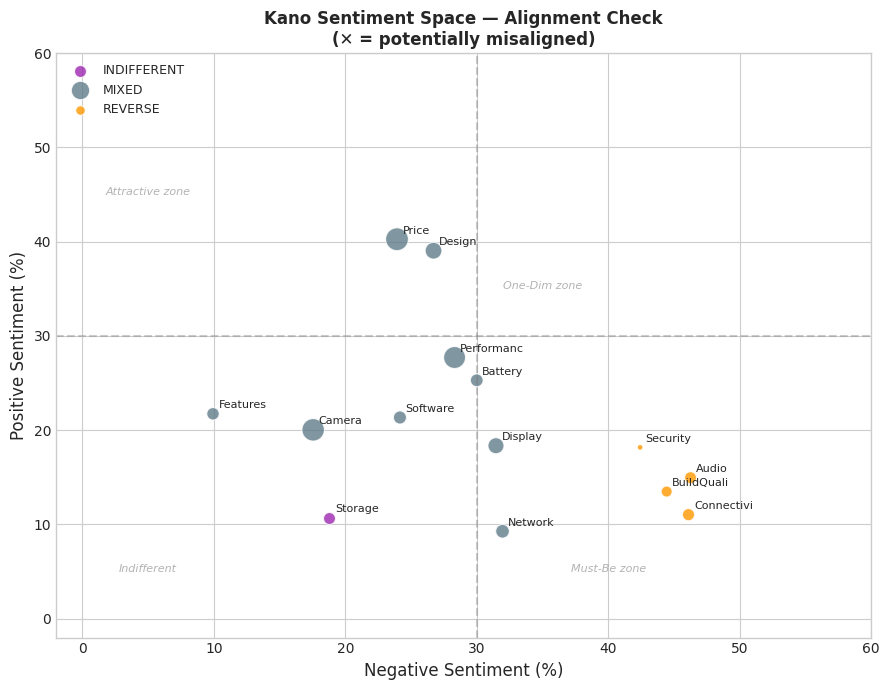

📊 Saved: eval_L3_alignment.png


In [13]:
# Sentiment space scatter
cat_colors = {
    'MUST-BE': '#F44336', 'ATTRACTIVE': '#2196F3',
    'ONE-DIMENSIONAL': '#4CAF50', 'INDIFFERENT': '#9C27B0',
    'REVERSE': '#FF9800', 'MIXED': '#607D8B',
}

fig, ax = plt.subplots(figsize=(9, 7))
for cat, grp in df_kano.groupby('kano_category'):
    sc = ax.scatter(
        grp['negative_pct'], grp['positive_pct'],
        s=grp['total_mentions'] / 2,
        c=cat_colors.get(cat, '#999'),
        label=cat, alpha=0.8, edgecolors='white', linewidths=0.8
    )
    # Mark misaligned with X
    mis = grp[grp['alignment'] == 'MISALIGNED']
    if len(mis):
        ax.scatter(mis['negative_pct'], mis['positive_pct'],
                   s=mis['total_mentions'] / 2,
                   marker='x', c='black', linewidths=2, zorder=5)

for _, row in df_kano.iterrows():
    ax.annotate(row['aspect'][:10],
                (row['negative_pct'], row['positive_pct']),
                xytext=(4, 4), textcoords='offset points', fontsize=8)

ax.axhline(30, ls='--', color='gray', alpha=0.4)
ax.axvline(30, ls='--', color='gray', alpha=0.4)
ax.set_xlabel('Negative Sentiment (%)', fontsize=12)
ax.set_ylabel('Positive Sentiment (%)', fontsize=12)
ax.set_title('Kano Sentiment Space — Alignment Check\n(✕ = potentially misaligned)',
             fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(-2, 60); ax.set_ylim(-2, 60)

# Quadrant labels
for txt, xy in [('Must-Be zone', (40, 5)), ('Attractive zone', (5, 45)),
                ('One-Dim zone', (35, 35)), ('Indifferent', (5, 5))]:
    ax.text(*xy, txt, fontsize=8, color='gray', alpha=0.6,
            ha='center', style='italic')

plt.tight_layout()
plt.savefig('eval_L3_alignment.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: eval_L3_alignment.png')

### 3-B. Kano Stability Test

Split the dataset in half and re-classify. High stability = robust findings.

In [14]:
def classify_kano(stats, total):
    if total < 5:
        return 'INSUFFICIENT'
    pos = (stats.get('positive', 0) / total) * 100
    neg = (stats.get('negative', 0) / total) * 100
    neu = (stats.get('neutral',  0) / total) * 100
    if neg > 60 and pos < 20:   return 'MUST-BE'
    if pos > 60 and neg < 20:   return 'ATTRACTIVE'
    if pos > 30 and neg > 30:   return 'ONE-DIMENSIONAL'
    if neu > 70:                return 'INDIFFERENT'
    if neg > pos and neg > 40:  return 'REVERSE'
    return 'MIXED'

def compute_kano_from_df(df_src):
    aspect_stats = {}
    for _, row in df_src.iterrows():
        aspects  = [a.strip() for a in str(row['aspects']).split(',')]
        sentims  = [s.strip() for s in str(row['sentiments']).split(',')]
        for asp, snt in zip(aspects, sentims):
            if asp not in aspect_stats:
                aspect_stats[asp] = {'positive': 0, 'neutral': 0, 'negative': 0}
            if snt in aspect_stats[asp]:
                aspect_stats[asp][snt] += 1
    return {asp: classify_kano(stats, sum(stats.values()))
            for asp, stats in aspect_stats.items()}

# Full dataset
cat_full = compute_kano_from_df(df_bert)

# Half splits
mid = len(df_bert) // 2
cat_h1 = compute_kano_from_df(df_bert.iloc[:mid])
cat_h2 = compute_kano_from_df(df_bert.iloc[mid:])

# Stability
aspects_common = set(cat_full) & set(cat_h1) & set(cat_h2)
stable = [a for a in aspects_common
          if cat_h1.get(a) == cat_h2.get(a) == cat_full.get(a)]
stability_rate = len(stable) / len(aspects_common) * 100 if aspects_common else 0

print(f'\n{'='*55}')
print(f'  LEVEL 3: KANO STABILITY TEST')
print(f'{'='*55}')
print(f'  Aspects tested   : {len(aspects_common)}')
print(f'  Stable aspects   : {len(stable)}')
print(f'  Stability rate   : {stability_rate:.1f}%')
if stability_rate >= 80:
    print('  ✅ HIGH STABILITY — findings are robust')
elif stability_rate >= 60:
    print('  ⚠️  MODERATE STABILITY — consider more data')
else:
    print('  ❌ LOW STABILITY — collect more labeled data')
print(f'{'='*55}\n')

# Comparison table
rows_stab = []
for asp in sorted(aspects_common):
    cf = cat_full.get(asp, 'N/A')
    c1 = cat_h1.get(asp, 'N/A')
    c2 = cat_h2.get(asp, 'N/A')
    rows_stab.append({
        'Aspect': asp, 'Full': cf, 'Half-1': c1, 'Half-2': c2,
        'Stable': '✅' if c1 == c2 == cf else '⚠️'
    })
df_stab = pd.DataFrame(rows_stab)
print(df_stab.to_string(index=False))


  LEVEL 3: KANO STABILITY TEST
  Aspects tested   : 14
  Stable aspects   : 12
  Stability rate   : 85.7%
  ✅ HIGH STABILITY — findings are robust

      Aspect    Full  Half-1  Half-2 Stable
       Audio REVERSE   MIXED REVERSE     ⚠️
     Battery   MIXED   MIXED   MIXED      ✅
BuildQuality REVERSE REVERSE REVERSE      ✅
      Camera   MIXED   MIXED   MIXED      ✅
Connectivity REVERSE REVERSE   MIXED     ⚠️
      Design   MIXED   MIXED   MIXED      ✅
     Display   MIXED   MIXED   MIXED      ✅
    Features   MIXED   MIXED   MIXED      ✅
     Network   MIXED   MIXED   MIXED      ✅
 Performance   MIXED   MIXED   MIXED      ✅
       Price   MIXED   MIXED   MIXED      ✅
    Security REVERSE REVERSE REVERSE      ✅
    Software   MIXED   MIXED   MIXED      ✅
     Storage   MIXED   MIXED   MIXED      ✅


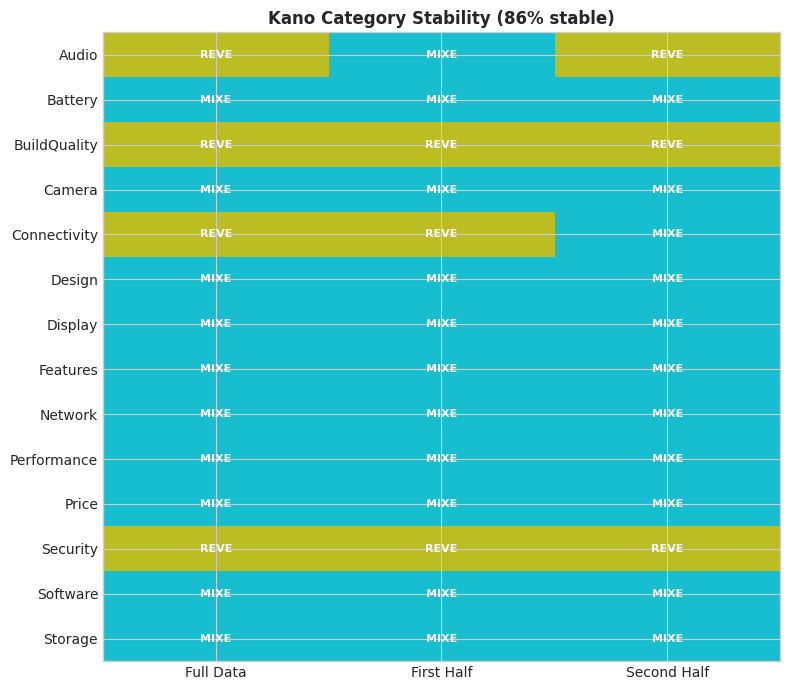

📊 Saved: eval_L3_stability.png


In [15]:
# Stability heatmap
encode_map = {
    'MUST-BE': 1, 'ATTRACTIVE': 2, 'ONE-DIMENSIONAL': 3,
    'INDIFFERENT': 4, 'REVERSE': 5, 'MIXED': 6,
    'INSUFFICIENT': 0, 'N/A': -1
}
label_map  = {v: k for k, v in encode_map.items()}

asp_sorted = sorted(aspects_common)
heat_data  = np.array([[encode_map.get(cat_full.get(a, 'N/A'), -1),
                         encode_map.get(cat_h1.get(a, 'N/A'), -1),
                         encode_map.get(cat_h2.get(a, 'N/A'), -1)]
                        for a in asp_sorted])

fig, ax = plt.subplots(figsize=(8, max(5, len(asp_sorted) * 0.5)))
im = ax.imshow(heat_data, cmap='tab10', aspect='auto', vmin=0, vmax=6)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Full Data', 'First Half', 'Second Half'])
ax.set_yticks(range(len(asp_sorted)))
ax.set_yticklabels(asp_sorted)

for i in range(len(asp_sorted)):
    for j in range(3):
        code = heat_data[i, j]
        ax.text(j, i, label_map.get(code, '')[:4],
                ha='center', va='center', fontsize=8, color='white',
                fontweight='bold')

ax.set_title(f'Kano Category Stability ({stability_rate:.0f}% stable)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('eval_L3_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: eval_L3_stability.png')

---
## Final Summary Dashboard

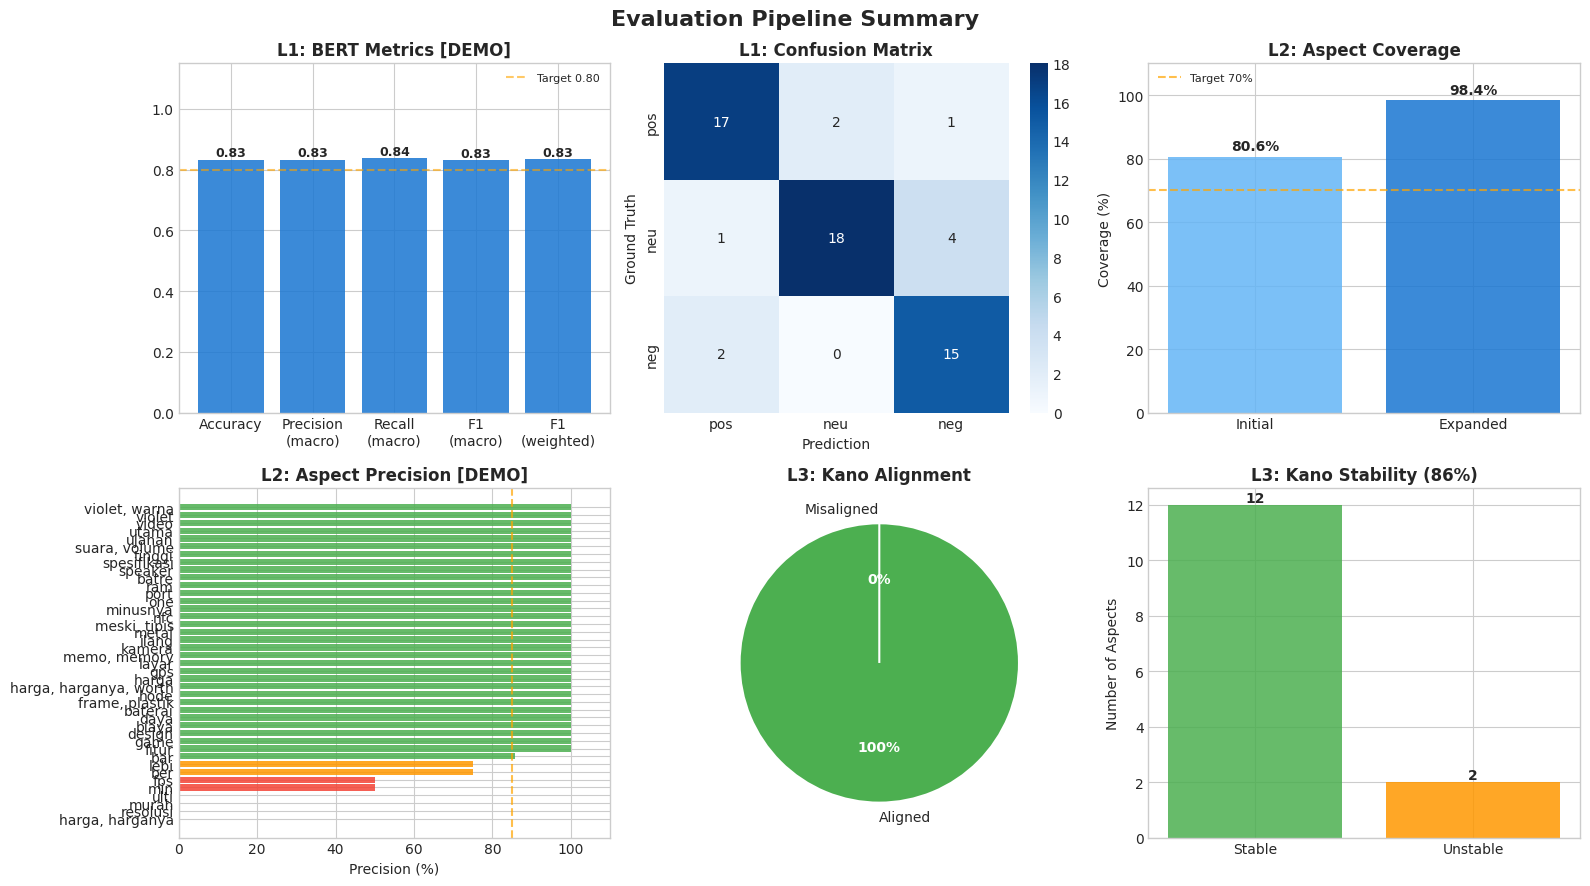

📊 Saved: eval_summary_dashboard.png


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Evaluation Pipeline Summary', fontsize=16, fontweight='bold')

# ── Panel 1: L1 metrics bar ───────────────────────────────────────────────────
ax = axes[0][0]
metrics = ['Accuracy', 'Precision\n(macro)', 'Recall\n(macro)',
           'F1\n(macro)', 'F1\n(weighted)']
values  = [acc, prec_macro, rec_macro, f1_macro, f1_weighted]
bars = ax.bar(metrics, values, color='#1976D2', alpha=0.85)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.axhline(0.80, ls='--', color='orange', alpha=0.6, label='Target 0.80')
ax.set_title(f'L1: BERT Metrics{" [DEMO]" if DEMO_MODE else ""}', fontweight='bold')
ax.legend(fontsize=8)

# ── Panel 2: L1 Confusion (raw) ───────────────────────────────────────────────
ax = axes[0][1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['pos', 'neu', 'neg'],
            yticklabels=['pos', 'neu', 'neg'], ax=ax)
ax.set_title('L1: Confusion Matrix', fontweight='bold')
ax.set_ylabel('Ground Truth')
ax.set_xlabel('Prediction')

# ── Panel 3: L2 Coverage ─────────────────────────────────────────────────────
ax = axes[0][2]
ax.bar(['Initial', 'Expanded'], [cov_init, cov_final],
       color=['#64B5F6', '#1976D2'], alpha=0.85)
ax.axhline(70, ls='--', color='orange', alpha=0.7, label='Target 70%')
ax.set_ylim(0, 110)
ax.set_ylabel('Coverage (%)')
ax.set_title('L2: Aspect Coverage', fontweight='bold')
for i, v in enumerate([cov_init, cov_final]):
    ax.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')
ax.legend(fontsize=8)

# ── Panel 4: L2 Precision per aspect ─────────────────────────────────────────
ax = axes[1][0]
colors_p = ['#F44336' if p < 70 else '#FF9800' if p < 85 else '#4CAF50'
            for p in precision_by_aspect['precision_pct']]
ax.barh(precision_by_aspect.index, precision_by_aspect['precision_pct'],
        color=colors_p, alpha=0.85)
ax.axvline(85, ls='--', color='orange', alpha=0.7)
ax.set_xlabel('Precision (%)')
ax.set_title(f'L2: Aspect Precision{" [DEMO]" if DEMO_ASP else ""}', fontweight='bold')
ax.set_xlim(0, 110)

# ── Panel 5: L3 Alignment donut ───────────────────────────────────────────────
ax = axes[1][1]
n_aligned   = (df_kano['alignment'] == 'ALIGNED').sum()
n_misaligned= (df_kano['alignment'] == 'MISALIGNED').sum()
wedges, texts, auto = ax.pie(
    [n_aligned, n_misaligned],
    labels=['Aligned', 'Misaligned'],
    colors=['#4CAF50', '#F44336'],
    autopct='%1.0f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for t in auto: t.set_color('white'); t.set_fontweight('bold')
ax.set_title('L3: Kano Alignment', fontweight='bold')

# ── Panel 6: L3 Stability summary ────────────────────────────────────────────
ax = axes[1][2]
n_stable   = len(stable)
n_unstable = len(aspects_common) - n_stable
ax.bar(['Stable', 'Unstable'], [n_stable, n_unstable],
       color=['#4CAF50', '#FF9800'], alpha=0.85)
ax.text(0, n_stable + 0.1, f'{n_stable}', ha='center', fontweight='bold')
ax.text(1, n_unstable + 0.1, f'{n_unstable}', ha='center', fontweight='bold')
ax.set_ylabel('Number of Aspects')
ax.set_title(f'L3: Kano Stability ({stability_rate:.0f}%)', fontweight='bold')

plt.tight_layout()
plt.savefig('eval_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: eval_summary_dashboard.png')

In [17]:
print()
print('=' * 65)
print('  EVALUATION PIPELINE — COMPLETE REPORT')
print('=' * 65)
print()
print('  LEVEL 1 — BERT Sentiment Model')
print(f'    Accuracy          : {acc*100:.1f}%')
print(f'    F1 Macro          : {f1_macro:.3f}')
print(f'    F1 Weighted       : {f1_weighted:.3f}')
print(f'    Low-conf preds    : {low_conf:.1f}%  (<0.70 threshold)')
if DEMO_MODE:
    print('    ⚠️  Labels are SIMULATED — replace with real golden dataset')
print()
print('  LEVEL 2 — Aspect Detection')
print(f'    Coverage (initial): {cov_init:.1f}%')
print(f'    Coverage (final)  : {cov_final:.1f}%  (+{cov_final-cov_init:.1f} pp)')
print(f'    Overall precision : {overall_precision:.1f}%')
if DEMO_ASP:
    print('    ⚠️  Precision labels are SIMULATED')
print()
print('  LEVEL 3 — Kano Model Validity')
print(f'    Alignment rate    : {aligned_rate:.1f}%')
print(f'    Stability rate    : {stability_rate:.1f}%')
print()
print('  FILES SAVED')
for fn in ['eval_L1_confusion_matrix.png', 'eval_L1_confidence.png',
           'eval_L2_coverage.png', 'eval_L2_aspect_precision.png',
           'eval_L3_alignment.png', 'eval_L3_stability.png',
           'eval_summary_dashboard.png',
           'eval_golden_template.csv', 'eval_aspect_template.csv']:
    print(f'    • {fn}')
print()
print('  NEXT STEPS TO IMPROVE ACCURACY')
print('    1. Label eval_golden_template.csv → run L1 with real data')
print('    2. Label eval_aspect_template.csv  → run L2 with real precision')
print('    3. Upgrade PyTorch (pip install torch>=2.6 --index-url ...')
print('       cu128) to use the primary BERT model instead of fallback')
print('    4. Add HF_TOKEN env var to lift rate limits')
print('=' * 65)


  EVALUATION PIPELINE — COMPLETE REPORT

  LEVEL 1 — BERT Sentiment Model
    Accuracy          : 83.3%
    F1 Macro          : 0.833
    F1 Weighted       : 0.834
    Low-conf preds    : 14.5%  (<0.70 threshold)
    ⚠️  Labels are SIMULATED — replace with real golden dataset

  LEVEL 2 — Aspect Detection
    Coverage (initial): 80.6%
    Coverage (final)  : 98.4%  (+17.8 pp)
    Overall precision : 87.1%
    ⚠️  Precision labels are SIMULATED

  LEVEL 3 — Kano Model Validity
    Alignment rate    : 100.0%
    Stability rate    : 85.7%

  FILES SAVED
    • eval_L1_confusion_matrix.png
    • eval_L1_confidence.png
    • eval_L2_coverage.png
    • eval_L2_aspect_precision.png
    • eval_L3_alignment.png
    • eval_L3_stability.png
    • eval_summary_dashboard.png
    • eval_golden_template.csv
    • eval_aspect_template.csv

  NEXT STEPS TO IMPROVE ACCURACY
    1. Label eval_golden_template.csv → run L1 with real data
    2. Label eval_aspect_template.csv  → run L2 with real precision
 